# Imports + Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv(r"C:\Data Analytics\Projects\END TO END\TeleCom_Analysis\Dataset\cleaned_dataset\customers_clean.csv")
churn_status = pd.read_csv(r"C:\Data Analytics\Projects\END TO END\TeleCom_Analysis\Dataset\cleaned_dataset\churn_status_clean.csv", parse_dates=['churn_date'])
usage_data = pd.read_csv(r"C:\Data Analytics\Projects\END TO END\TeleCom_Analysis\Dataset\cleaned_dataset\usage_data_clean.csv", parse_dates=['month'])
complaints = pd.read_csv(r"C:\Data Analytics\Projects\END TO END\TeleCom_Analysis\Dataset\cleaned_dataset\complaints_clean.csv", parse_dates=['complaint_date'])

print(customers.shape, churn_status.shape, usage_data.shape, complaints.shape)

(50000, 8) (50000, 4) (300000, 6) (71584, 6)


# Tenure Buckets

In [2]:
def tenure_bucket(months): 
    if months <= 6 : 
        return 'New (0-6m)'
    elif months <= 24 : 
        return 'Growing (6-24m)'
    elif months <= 48:
        return 'Established (24-48m)'
    else:
        return 'Loyal (48m+)'

customers['tenure_bucket'] = customers['tenure_months'].apply(tenure_bucket)

print(customers[['tenure_months', 'tenure_bucket']].head(10))

   tenure_months         tenure_bucket
0             28  Established (24-48m)
1              4            New (0-6m)
2              4            New (0-6m)
3              5            New (0-6m)
4             16       Growing (6-24m)
5             21       Growing (6-24m)
6             11       Growing (6-24m)
7             32  Established (24-48m)
8             61          Loyal (48m+)
9              2            New (0-6m)


# Complaint Frequency Per Customer + High Complainer Flag

In [3]:
complaint_freq = complaints.groupby('customer_id').size().reset_index(name='total_complaints')

customers = customers.merge(complaint_freq, on='customer_id', how='left')

customers['total_complaints'] = customers['total_complaints'].fillna(0).astype(int)

customers['high_complainer'] = customers['total_complaints'].apply(lambda x: 'Yes' if x >= 3 else 'No')

print(customers[['customer_id', 'total_complaints', 'high_complainer']].head(10))

  customer_id  total_complaints high_complainer
0  CUST100000                 1              No
1  CUST100001                 0              No
2  CUST100002                 3             Yes
3  CUST100003                 3             Yes
4  CUST100004                 1              No
5  CUST100005                 3             Yes
6  CUST100006                 1              No
7  CUST100007                 0              No
8  CUST100008                 2              No
9  CUST100009                 2              No


# Usage Decline %

In [4]:
first_month = usage_data[usage_data['month']=='2025-08-01'][['customer_id','data_used_gb']].rename(columns={'data_used_gb':'first_month_usage'})

last_month = usage_data[usage_data['month']=='2026-01-01'][['customer_id','data_used_gb']].rename(columns={'data_used_gb':'last_month_usage'})

usage_trend = first_month.merge(last_month, on='customer_id')

usage_trend['usage_decline_pct'] = ((usage_trend['first_month_usage'] - usage_trend['last_month_usage']) / usage_trend['first_month_usage']) * 100

print(usage_trend.head(10))

  customer_id  first_month_usage  last_month_usage  usage_decline_pct
0  CUST100000              27.60             26.58           3.695652
1  CUST100001              28.95             27.33           5.595855
2  CUST100002               7.03              3.08          56.187767
3  CUST100003               8.32              6.67          19.831731
4  CUST100004              25.81             26.98          -4.533127
5  CUST100005               7.85              3.03          61.401274
6  CUST100006               4.19              4.88         -16.467780
7  CUST100007              22.08             24.81         -12.364130
8  CUST100008               5.72              6.65         -16.258741
9  CUST100009              27.73             10.28          62.928237


In [5]:
usage_trend = usage_trend.merge(churn_status[['customer_id','is_churned']], on='customer_id')

print(usage_trend.groupby('is_churned')['usage_decline_pct'].mean())

is_churned
0    -0.710324
1    59.736092
Name: usage_decline_pct, dtype: float64


In [6]:
customers = customers.merge(usage_trend[['customer_id', 'usage_decline_pct']], on='customer_id', how='left')

customers['usage_decline_pct'] = customers['usage_decline_pct'].fillna(0)

print(customers.columns.tolist())

['customer_id', 'city', 'age', 'gender', 'plan_type', 'contract_type', 'tenure_months', 'monthly_charges', 'tenure_bucket', 'total_complaints', 'high_complainer', 'usage_decline_pct']


In [7]:
customers = customers.merge(churn_status[['customer_id', 'is_churned']], on='customer_id', how='left')

print(customers.shape)
print(customers['is_churned'].value_counts())

(50000, 13)
is_churned
0    39075
1    10925
Name: count, dtype: int64


In [8]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

import os

charts_path = 'Charts/'
os.makedirs(charts_path, exist_ok=True)

print("Folder exists:", os.path.exists(charts_path))

Folder exists: True


# Chart 1 — Churn Rate by Contract Type

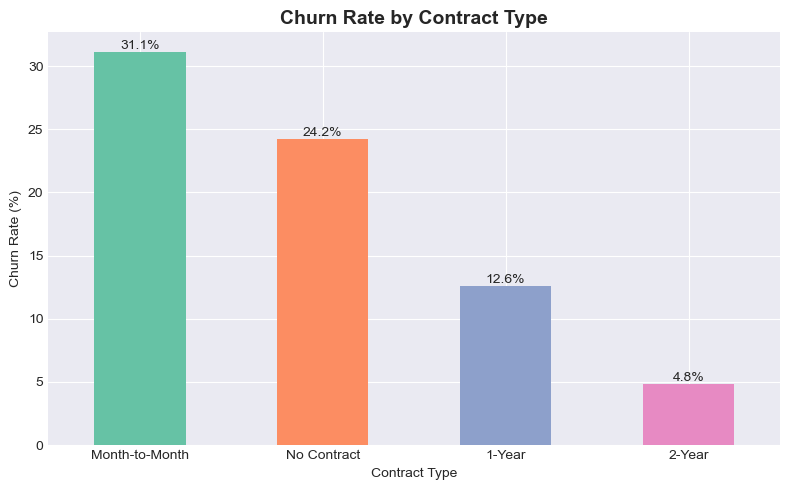

In [9]:
churn_by_contract = customers.groupby('contract_type')['is_churned'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8,5))
ax = churn_by_contract.plot(kind='bar', color=sns.color_palette('Set2'))
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(charts_path + 'chart1_churn_by_contract.png', dpi=150)
plt.show()

### Insight: Churn Rate by Contract Type

I found that customers on a **Month-to-Month contract have the highest churn rate at 31.1%**, 
compared to just **4.8% for customers on a 2-Year contract** that's about 6.5 times higher.

Customers with **No Contract (Prepaid users) churn at 24.2%**, and **1-Year contract customers 
churn at 12.6%** - so the pattern is very clear: the longer the commitment, the lower the churn.

**Why this matters for the business:**
This tells us that contract length is one of the strongest drivers of customer retention. 
If the company wants to reduce churn, one of the simplest actions would be to actively 
push customers on flexible plans toward longer-term contracts - maybe through discounts 
or loyalty rewards for signing a 1-Year or 2-Year plan. Even converting a portion of the 
Month-to-Month customers to 1-Year contracts could meaningfully bring down the overall churn rate.

# Chart 2 — Churn Rate by Tenure Bucket

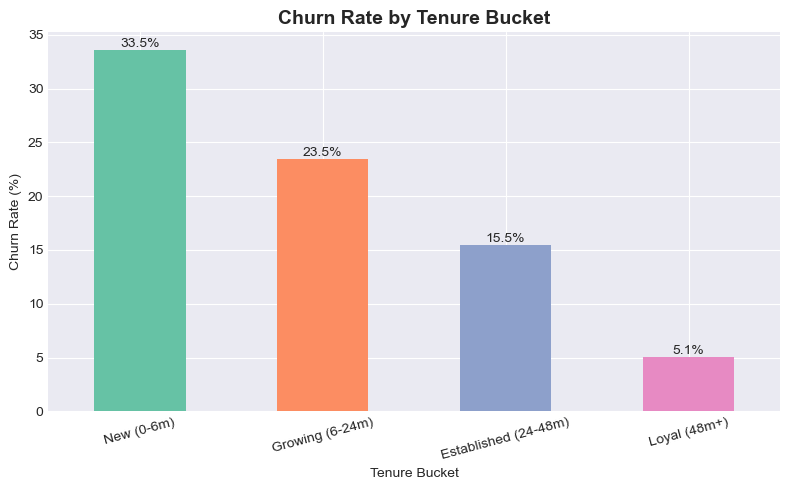

In [10]:
tenure_order = ['New (0-6m)', 'Growing (6-24m)', 'Established (24-48m)', 'Loyal (48m+)']

churn_by_tenure = customers.groupby('tenure_bucket')['is_churned'].mean().reindex(tenure_order) * 100

plt.figure(figsize=(8,5))
ax = churn_by_tenure.plot(kind='bar', color=sns.color_palette('Set2'))
plt.title('Churn Rate by Tenure Bucket', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Bucket')
plt.ylabel('Churn Rate (%)')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(charts_path + 'chart2_churn_by_tenure.png', dpi=150)
plt.show()

### Insight: Churn Rate by Tenure Bucket

I found a clear pattern here - **new customers (0-6 months) churn at 33.5%**, which is the 
highest among all groups. As tenure increases, churn drops steadily: **23.5% for Growing 
customers (6-24 months), 15.5% for Established customers (24-48 months), and just 5.1% 
for Loyal customers (48+ months)**.

That means a brand new customer is about **6.5 times more likely to churn** than a customer 
who has been with the company for 4+ years.

**Why this matters for the business:**
This shows that the first 6 months are the most critical period for retention. Customers who 
survive this initial phase become significantly more loyal over time. The company should focus 
retention efforts - like onboarding support, welcome offers, or proactive check-ins - specifically 
on customers in their first 6 months, since that's where the biggest drop-off risk lies.

# Chart 3 — Churn Rate by City

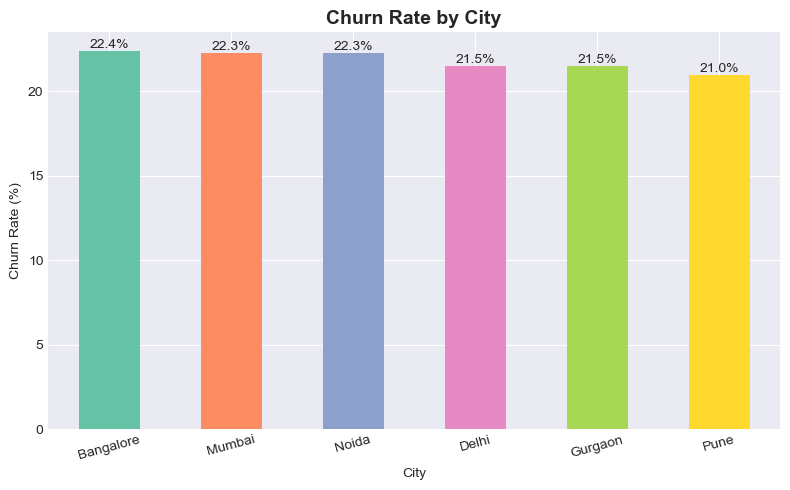

In [11]:
churn_by_city = customers.groupby('city')['is_churned'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8,5))
ax = churn_by_city.plot(kind='bar', color=sns.color_palette('Set2'))
plt.title('Churn Rate by City', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Churn Rate (%)')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(charts_path + 'chart3_churn_by_city.png', dpi=150)
plt.show()

### Insight: Churn Rate by City

Unlike contract type and tenure, city doesn't show a strong pattern here. Churn rates 
across all six cities are fairly close - ranging from **21.0% in Pune to 22.4% in Bangalore**, 
a difference of just 1.4 percentage points.

**Why this matters for the business:**
This tells us that churn in this business is not being driven by geography - it's a more 
universal problem affecting customers everywhere similarly. That means the company shouldn't 
prioritize city-specific retention strategies (like city-wise network upgrades), and should 
instead focus its resources on the factors that do show a strong impact- like contract type 
and customer tenure, which we saw earlier.

# Chart 4 — Usage Decline % Distribution (Churned vs Non-Churned)

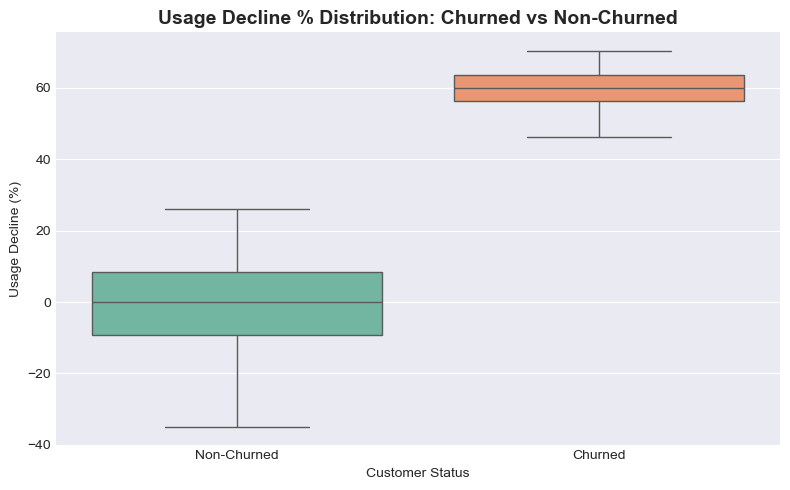

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=customers, x='is_churned', y='usage_decline_pct', hue='is_churned', palette='Set2', legend=False)
plt.title('Usage Decline % Distribution: Churned vs Non-Churned', fontsize=14, fontweight='bold')
plt.xlabel('Customer Status')
plt.ylabel('Usage Decline (%)')
plt.xticks([0, 1], ['Non-Churned', 'Churned'])
plt.tight_layout()
plt.savefig(charts_path + 'chart4_usage_decline_boxplot.png', dpi=150)
plt.show()

### Insight: Usage Decline % Distribution — Churned vs Non-Churned

This boxplot shows an even clearer picture than the average alone. Non-churned customers' 
usage decline is tightly clustered between **-8% and +8%**, meaning most of them kept their 
usage roughly stable. Churned customers, on the other hand, cluster between **57% and 63%** 
decline - a massive and consistent drop.

What stands out most is that **there's no overlap between the two groups** — even the 
non-churned customer with the highest decline (about 26%) still falls well short of the 
churned customer with the lowest decline (about 47%).

**Why this matters for the business:**
This makes usage decline one of the most reliable early-warning signals for churn. If the 
company sets up an automated alert for any customer whose usage drops by more than 30-40%, 
it could flag at-risk customers well before they actually leave - giving the retention team 
a real window to step in with an offer or outreach call.

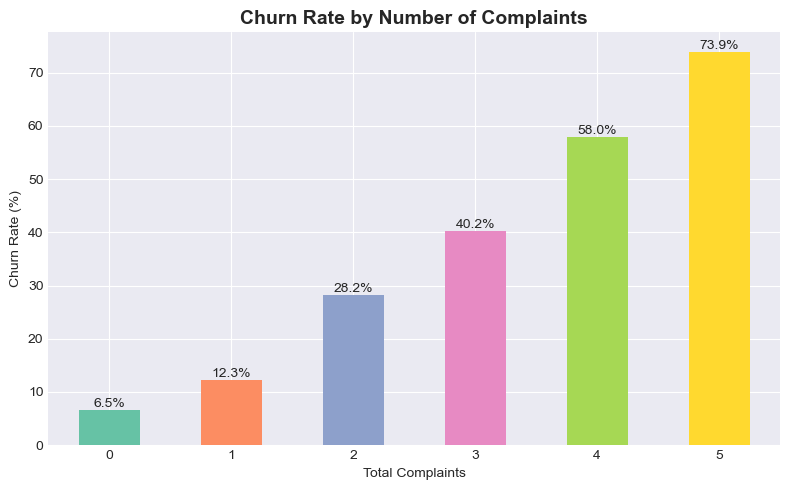

In [13]:
churn_by_complaints = customers.groupby('total_complaints')['is_churned'].mean() * 100

plt.figure(figsize=(8,5))
ax = churn_by_complaints.plot(kind='bar', color=sns.color_palette('Set2'))
plt.title('Churn Rate by Number of Complaints', fontsize=14, fontweight='bold')
plt.xlabel('Total Complaints')
plt.ylabel('Churn Rate (%)')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(charts_path + 'chart5_churn_by_complaints.png', dpi=150)
plt.show()

### Insight: Churn Rate by Number of Complaints

This chart shows a very clear, almost linear relationship between complaints and churn. 
Customers with **0 complaints churn at just 6.5%**, but this climbs steadily as complaints 
increase: **12.3% at 1 complaint, 28.2% at 2, 40.2% at 3, 58.0% at 4, and a massive 73.9% 
at 5 complaints**.

That means a customer with 5 complaints is roughly **11 times more likely to churn** than 
a customer with none.

**Why this matters for the business:**
This is one of the most actionable insights in the whole analysis. The company doesn't need 
complex prediction models to spot high-risk customers - a simple rule like "flag any customer 
with 3 or more complaints for priority retention outreach" would already catch a large portion 
of likely churners. This also suggests that fixing the root causes behind repeat complaints 
(not just resolving each ticket individually) could have a direct, measurable impact on 
reducing churn.

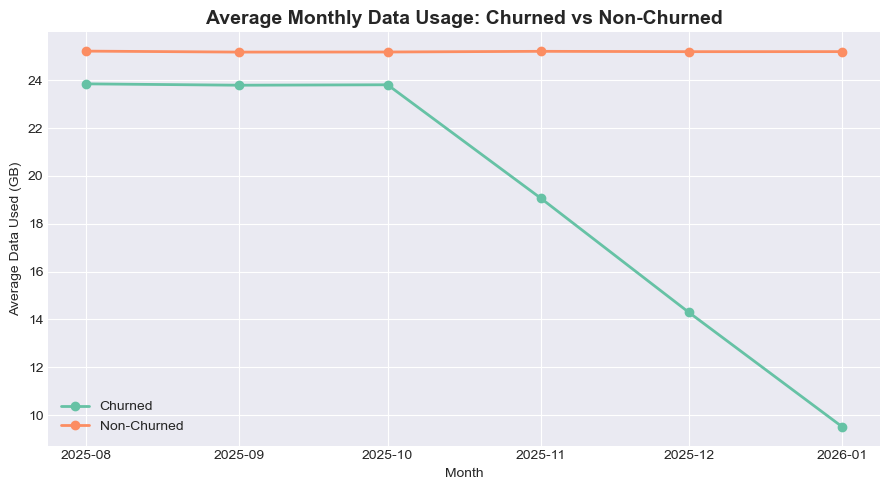

In [14]:
monthly_avg = usage_data.merge(churn_status[['customer_id','is_churned']], on='customer_id')
monthly_avg = monthly_avg.groupby(['month', 'is_churned'])['data_used_gb'].mean().reset_index()

churned_trend = monthly_avg[monthly_avg['is_churned']==1].sort_values('month')
non_churned_trend = monthly_avg[monthly_avg['is_churned']==0].sort_values('month')

plt.figure(figsize=(9,5))
plt.plot(churned_trend['month'], churned_trend['data_used_gb'], marker='o', label='Churned', linewidth=2)
plt.plot(non_churned_trend['month'], non_churned_trend['data_used_gb'], marker='o', label='Non-Churned', linewidth=2)
plt.title('Average Monthly Data Usage: Churned vs Non-Churned', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Data Used (GB)')
plt.legend()
plt.tight_layout()
plt.savefig(charts_path + 'chart6_monthly_usage_trend.png', dpi=150)
plt.show()

### Insight: Monthly Usage Trend — Churned vs Non-Churned

This trend line makes the churn pattern very visual. Non-churned customers maintain a 
**flat, stable usage around 25 GB every month** from August through January - no real change.

Churned customers, however, follow a completely different path. Their usage stays close to 
non-churned levels through October (~24 GB), but then **drops sharply starting in November** - 
falling to 19 GB in November, 14.3 GB in December, and just 9.5 GB by January. That's roughly 
a **60% drop in just 3 months**.

**Why this matters for the business:**
The timing here is the key insight - the decline doesn't start gradually from day one, it 
begins about 2-3 months before the customer actually leaves. This gives the company a real 
window to act. If the retention team monitors month-over-month usage and flags any customer 
whose usage drops sharply for two consecutive months, they could catch at-risk customers 
around November-level behavior - well before they reach the point of leaving.

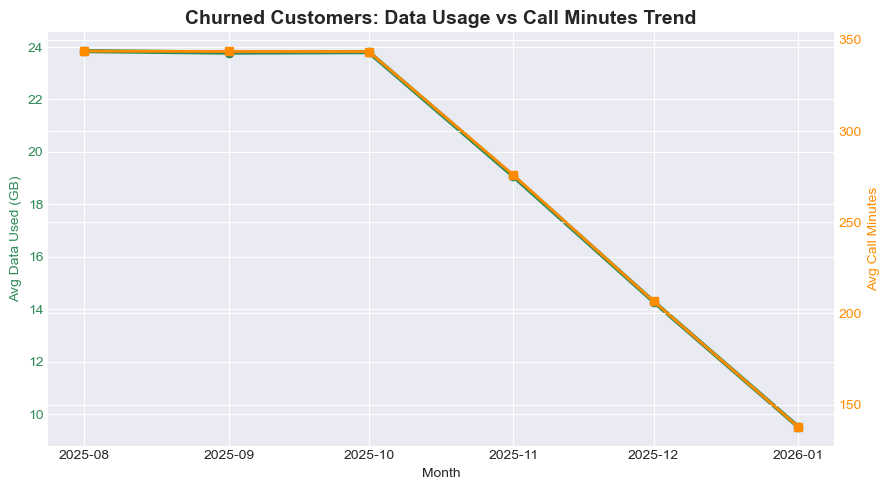

In [16]:
monthly_churned = usage_data.merge(churn_status[['customer_id','is_churned']], on='customer_id')
monthly_churned = monthly_churned[monthly_churned['is_churned']==1]
monthly_churned = monthly_churned.groupby('month')[['data_used_gb', 'calls_minutes']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(9,5))

ax1.plot(monthly_churned['month'], monthly_churned['data_used_gb'], color='seagreen', marker='o', linewidth=3, linestyle='-', label='Data Usage (GB)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Data Used (GB)', color='seagreen')
ax1.tick_params(axis='y', labelcolor='seagreen')

ax2 = ax1.twinx()
ax2.plot(monthly_churned['month'], monthly_churned['calls_minutes'], color='darkorange', marker='s', linewidth=2, label='Call Minutes')
ax2.set_ylabel('Avg Call Minutes', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Churned Customers: Data Usage vs Call Minutes Trend', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig(charts_path + 'chart7_data_vs_calls_twinx.png', dpi=150)
plt.show()

### Insight: Data Usage vs Call Minutes Trend (Churned Customers)

Interestingly, when I plotted data usage and call minutes together, both lines moved in 
**almost perfect sync** - data usage and call minutes decline at nearly identical rates 
starting in November, both dropping roughly 60% by January.

**Why this matters for the business:**
This tells us that churn isn't isolated to one type of usage - when a customer starts 
disengaging, they pull back across all touchpoints (data, calls) at the same time, not just 
one. This means the company doesn't need to build separate early-warning systems for data 
usage and call usage - monitoring either one closely would catch the same at-risk customers, 
since they move together.

# Chart 8 — Correlation Heatmap

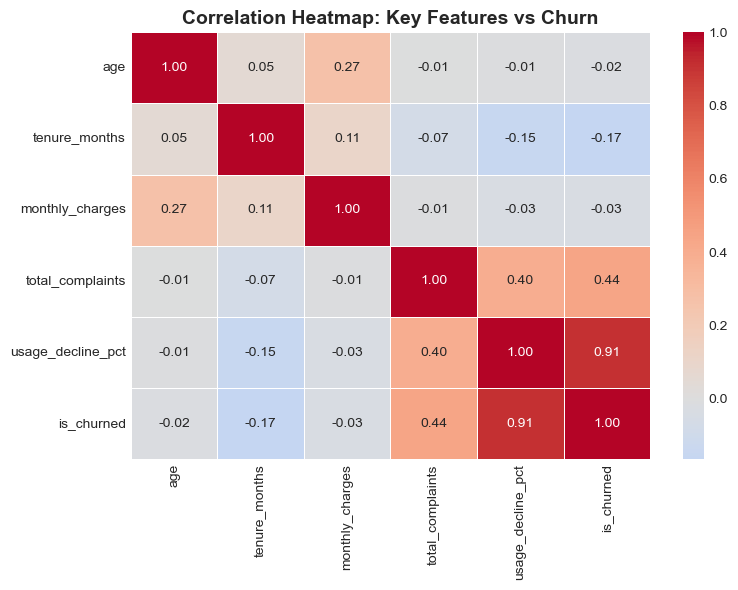

In [17]:
correlation_cols = ['age', 'tenure_months', 'monthly_charges', 'total_complaints', 'usage_decline_pct', 'is_churned']

corr_matrix = customers[correlation_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap: Key Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(charts_path + 'chart8_correlation_heatmap.png', dpi=150)
plt.show()

### Insight: Correlation Heatmap — Key Features vs Churn

I compared how strongly each feature is related to churn, using a number between -1 and +1. 
The closer this number is to +1, the more strongly two things move together.

**Usage decline % has a score of 0.91 with churn** - this is an extremely strong relationship. 
It means when a customer's usage drops a lot, they are almost always the ones who end up 
churning. This is by far the most powerful signal in the entire dataset.

**Total complaints has a score of 0.44 with churn** - a moderate relationship. More complaints 
generally means higher chances of churning, but it's not as strong or as reliable as usage decline.

**Tenure has a score of -0.17 with churn** - a weak relationship. This confirms what I saw 
earlier: customers who've been around longer churn a little less, but it's not a major factor 
on its own.

**Age and monthly charges scored close to 0** with churn (-0.02 and -0.03) - meaning they 
have almost no relationship with churn at all. A customer's age or how much they pay isn't 
really what's driving them to leave.

**Why this matters for the business:**
This tells the company exactly where to focus. If they only had time or budget to track one 
thing to predict churn, it should be usage decline - not age, not pricing, not even complaints. 
A simple alert system that flags customers with a sharp drop in usage would catch most 
at-risk customers before they actually leave.

# Chart 9 — Plan Type Distribution Across Cities

In [18]:
city_plan_counts = customers.groupby(['city', 'plan_type']).size().reset_index(name='count')

pivot_table = city_plan_counts.pivot(index='city', columns='plan_type', values='count')
print(pivot_table)
print()

melted = pd.melt(pivot_table.reset_index(), id_vars='city', var_name='plan_type', value_name='count')
print(melted.head())

plan_type  Broadband  Postpaid  Prepaid
city                                   
Bangalore       1972      2582     2988
Delhi           2582      3389     4032
Gurgaon         2637      3393     4050
Mumbai          2519      3445     4002
Noida           1887      2533     3012
Pune            1292      1622     2063

        city  plan_type  count
0  Bangalore  Broadband   1972
1      Delhi  Broadband   2582
2    Gurgaon  Broadband   2637
3     Mumbai  Broadband   2519
4      Noida  Broadband   1887


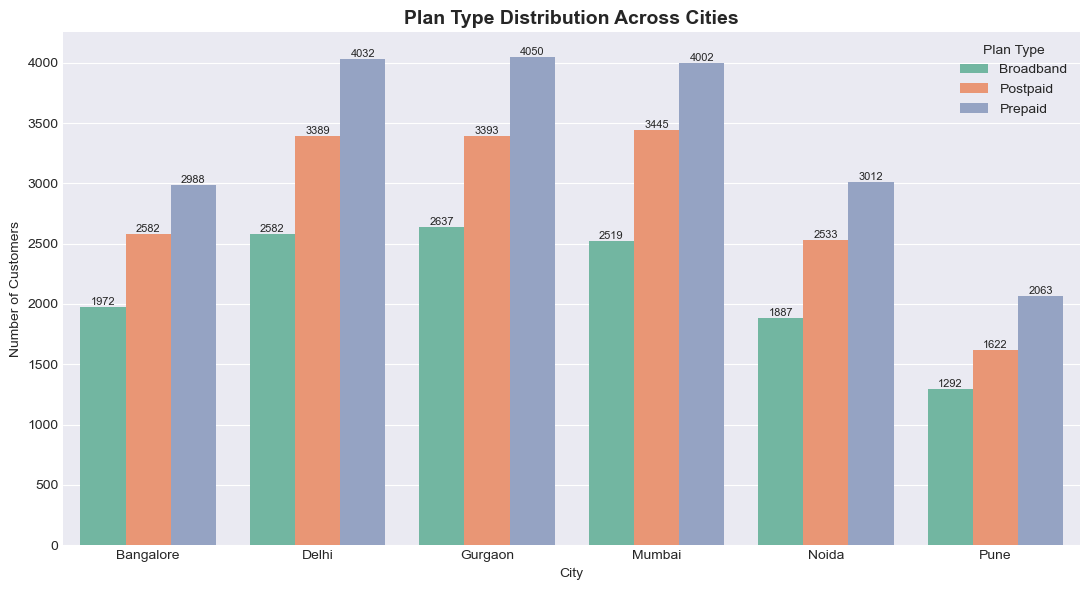

In [21]:
city_plan_counts = customers.groupby(['city', 'plan_type']).size().reset_index(name='count')

plt.figure(figsize=(11,6))
ax = sns.barplot(data=city_plan_counts, x='city', y='count', hue='plan_type', palette='Set2')
plt.title('Plan Type Distribution Across Cities', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.legend(title='Plan Type')

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.tight_layout()
plt.savefig(charts_path + 'chart9_plan_by_city.png', dpi=150)
plt.show()

### Insight: Plan Type Distribution Across Cities

I looked at how many customers each city has for each plan type - Prepaid, Postpaid, 
and Broadband - to see if any city prefers a different plan than the others.

**In every city, the order is exactly the same:** Prepaid has the most customers, 
Postpaid comes second, and Broadband always has the fewest. No city breaks this pattern.

For example, in **Delhi**: Prepaid = 4032 customers, Postpaid = 3389 customers, 
Broadband = 2582 customers. In **Mumbai**: Prepaid = 4002, Postpaid = 3445, 
Broadband = 2519. Even in **Pune**, which has the smallest customer base overall, 
the same order holds: Prepaid = 2063, Postpaid = 1622, Broadband = 1292.

So while the total number of customers changes from city to city (Delhi and Gurgaon 
have the most, Pune has the least), **the ranking of which plan is most popular never 
changes.**

**Why this matters for the business:**
This tells the company that plan preference is a nationwide pattern, not a city-specific 
one. They don't need to design different plan-promotion strategies for different cities -

a single strategy to push Postpaid or Broadband upgrades (the less popular plans) would 
work consistently well no matter which city they're targeting.

# Chart 10 — Revenue at Risk (Churned Customers' Monthly Charges by Plan Type)

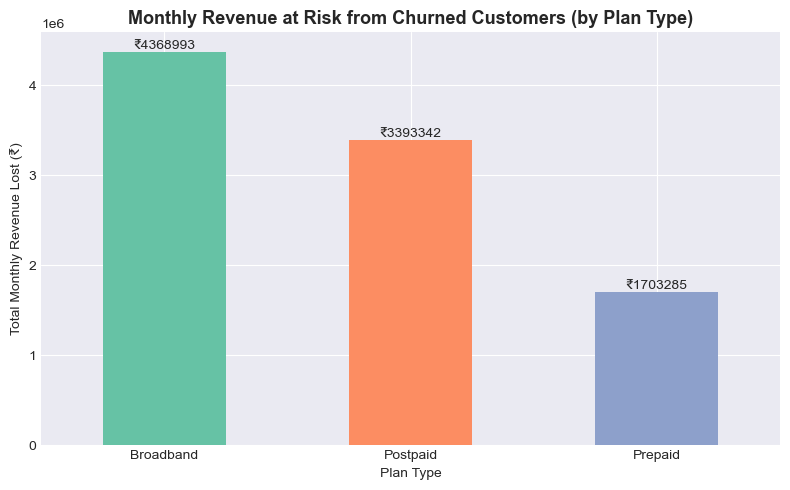

Total Monthly Revenue at Risk: ₹ 9465619.47


In [22]:
revenue_at_risk = customers[customers['is_churned']==1].groupby('plan_type')['monthly_charges'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = revenue_at_risk.plot(kind='bar', color=sns.color_palette('Set2'))
plt.title('Monthly Revenue at Risk from Churned Customers (by Plan Type)', fontsize=13, fontweight='bold')
plt.xlabel('Plan Type')
plt.ylabel('Total Monthly Revenue Lost (₹)')
ax.bar_label(ax.containers[0], fmt='₹%.0f')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(charts_path + 'chart10_revenue_at_risk.png', dpi=150)
plt.show()

print("Total Monthly Revenue at Risk: ₹", round(revenue_at_risk.sum(), 2))

### Insight: Monthly Revenue at Risk from Churned Customers

I calculated how much monthly revenue the company is losing from churned customers, 
broken down by plan type - and the ranking here is opposite to what I saw in the earlier 
city chart, where Broadband had the fewest customers.

**Broadband customers who churned are costing the company the most: ₹43,68,993 per month**, 
even though Broadband had the smallest number of churned customers among the three plans. 
Postpaid comes next at **₹33,93,342 per month**, and Prepaid is the lowest at **₹17,03,285 
per month**, despite Prepaid having the largest number of churned customers overall.

The reason for this is simple - a Broadband customer pays much more per month (₹800 to 
₹2500) than a Prepaid customer (₹200 to ₹500), so losing one Broadband customer hurts 
revenue far more than losing one Prepaid customer, even though it's fewer people.

Altogether, the company is losing **₹94,65,619 every month** from churned customers 
across all plans.

**Why this matters for the business:**
This tells the company that not all churned customers are equally costly. If the retention 
team has limited resources, they should prioritize saving Broadband and Postpaid customers 
first — since retaining even a small number of high-value customers protects far more 
revenue than retaining a larger number of low-value Prepaid customers.